### Section 2 — Analysis (4b)
* Test flucutations on bilateral exchange rates
* Regress share_raw on available controls (prefer inflation over price_index if both present).
* Report OLS, OLS(HC1 robust), and OLS(HAC Newey–West); print a compact LaTeX table.
* lot residual diagnostics (time path, index plot, histogram).

In [1]:
import pandas as pd
import numpy as np
import pylab as plt
import seaborn as sns
import seaborn as sns
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

## Correct by bilateral exchange rates

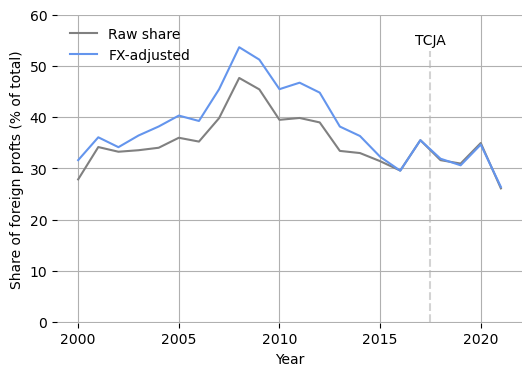

In [2]:
# === ANALYSIS (A/2): EXCHANGE-RATE ANALYSIS ===
# Load the combined BEA series saved earlier and compare raw vs FX-adjusted shares.

df_bea_comb = pd.read_csv("data/bea_sf_combined.csv", sep="\t", index_col=0)
df_bea_comb.index.name = "year"
df_bea_comb = df_bea_comb.loc[2000:2021]
# Quick comparison plot (no seaborn; default colors)
plt.figure(figsize=(6,4))
plt.plot(df_bea_comb.index, df_bea_comb["share_raw"], label="Raw share", color="gray")
if "share_fx_adj" in df_bea_comb.columns:
    plt.plot(df_bea_comb.index, df_bea_comb["share_fx_adj"],  label="FX-adjusted",  color="cornflowerblue")
plt.ylim(-0.1,0.6*100)
plt.ylabel("Share of foreign profts (% of total)")
plt.legend(loc=2, frameon=False)

plt.plot([2017.5, 2017.5], [0, 0.53*100], "--", color="lightgray", zorder=1)
sns.despine()
plt.xlabel("Year")
plt.annotate("TCJA", (2017.5, 0.55*100), ha="center", va="center")
plt.grid()
sns.despine(left=True, bottom=True)
plt.savefig("results/figures/currency_adjusted_official.pdf", bbox_inches="tight")



## Correct by business cycle

In [3]:
# === ANALYSIS (B/2): BUSINESS-CYCLE REGRESSION ===
# Read df_share_controls from disk and run OLS with HC1 and HAC (Newey–West) SEs.

in_path = "data/df_share_controls.csv"
df_share_controls = pd.read_csv(in_path, index_col=0)
df_share_controls.index.name = "year"

# Design matrix (your spec): share_raw ~ row_growth + us_growth + price_index
X = sm.add_constant(df_share_controls[["row_growth", "us_growth", "price_index"]], has_constant="add")
y = df_share_controls["share_raw"]

ols = sm.OLS(y, X, missing="drop").fit()
ols_hc1 = ols.get_robustcov_results(cov_type="HC1")

def newey_west_lags(T: int) -> int:
    """Newey–West rule-of-thumb: floor(4 * (T/100)^(2/9))."""
    return max(1, int(np.floor(4 * (T / 100.0) ** (2.0 / 9.0))))

T = int(ols.nobs)
L = newey_west_lags(T)
ols_hac = ols.get_robustcov_results(cov_type="HAC", maxlags=L)

print("=== OLS ===")
print(ols.summary())
print("\n=== OLS (HC1 robust) ===")
print(ols_hc1.summary())
print(f"\n=== OLS (HAC Newey–West, maxlags={L}) ===")
print(ols_hac.summary())

# Compact LaTeX table
tbl = summary_col(
    [ols, ols_hc1, ols_hac],
    model_names=["OLS", "OLS (HC1)", "OLS (HAC)"],
    stars=False,
    float_format="%.3f",
    info_dict={"N": lambda x: f"{int(x.nobs)}", "R2": lambda x: f"{x.rsquared:.3f}"},
)
print("\n--- LaTeX table ---\n")
print(tbl.as_latex())

# Residual diagnostics
resid = ols.resid


=== OLS ===
                            OLS Regression Results                            
Dep. Variable:              share_raw   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     24.84
Date:                Fri, 19 Dec 2025   Prob (F-statistic):           1.14e-07
Time:                        11:27:29   Log-Likelihood:                -70.402
No. Observations:                  29   AIC:                             148.8
Df Residuals:                      25   BIC:                             154.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          35.7909      1.298     

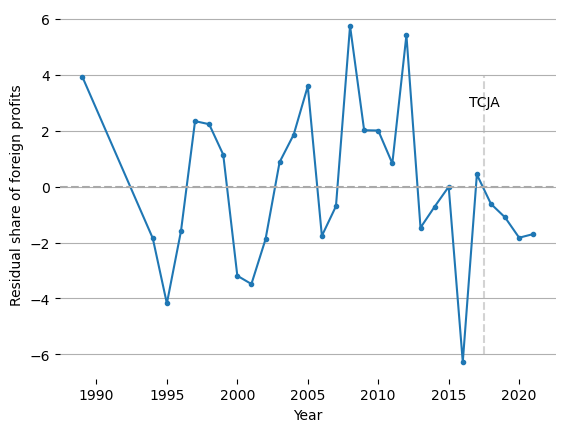

In [4]:


# 1) Residuals over time
plt.plot(df_share_controls.index, resid, marker=".")
plt.axhline(0, linestyle="--", color="darkgray")
plt.xlabel("Year")
plt.ylabel("Residual share of foreign profits")
plt.plot([2017.5, 2017.5], [-6, 4], "--", color="lightgray", zorder=1)

plt.annotate("TCJA", (2017.5, 3), ha="center", va="center")



sns.despine(left=True, bottom=True)
plt.grid(axis="y")
plt.savefig("results/figures/corrected_share_foreign_profits.pdf", bbox_inches="tight")
